<a href="https://colab.research.google.com/github/lukasakar19-byte/Jaringan-Saraf-Tiruan/blob/main/PROJEK_UAS_JST_LUKAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron, SGDRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error

# Dataset A

## Analisis Karakteristik Data

### Analisis Hubungan Antar Variabel

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')
data = pd.read_csv("/content/gdrive/My Drive/jst/A.csv")
data.info()

print("\n=== Data ===")
print(data)

X = data[['x1', 'x2']]
y = data['y']

Mounted at /content/gdrive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      500 non-null    float64
 1   x2      500 non-null    float64
 2   y       500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB

=== Data ===
            x1         x2  y
0    31.474124  30.835874  1
1    33.825441  41.079863 -1
2    35.596026  47.920462 -1
3    30.110042  33.246890  1
4    34.001953  46.678381 -1
..         ...        ... ..
495  36.611724  33.731549  1
496  30.166745  33.826019  1
497  37.299209  36.630090  1
498  33.056230  30.185980  1
499  32.697502  39.090252 -1

[500 rows x 3 columns]


          x1        x2         y
x1  1.000000  0.001760  0.385411
x2  0.001760  1.000000 -0.698603
y   0.385411 -0.698603  1.000000


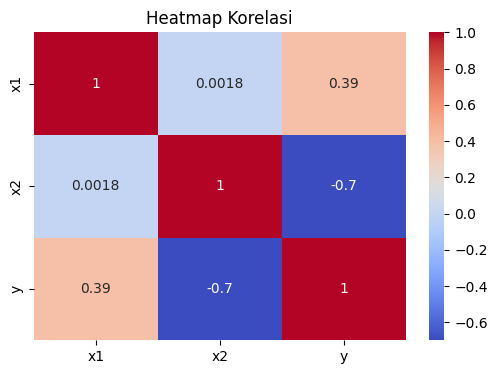

In [4]:
corr = data.corr()
print(corr)

# Visualisasi heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

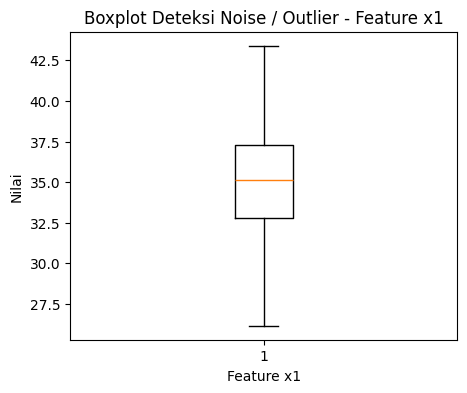

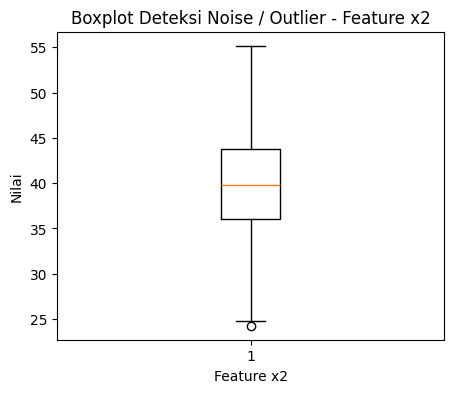

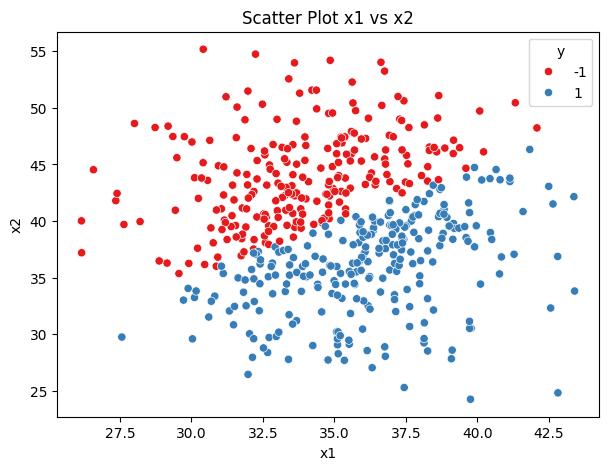

In [5]:
for col in ['x1', 'x2']:
    plt.figure(figsize=(5, 4))
    plt.boxplot(data[col])
    plt.title(f'Boxplot Deteksi Noise / Outlier - Feature {col}')
    plt.xlabel(f'Feature {col}')
    plt.ylabel('Nilai')
    plt.show()

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=data['x1'],
    y=data['x2'],
    hue=data['y'],
    palette='Set1'
)

plt.title('Scatter Plot x1 vs x2')
plt.show()

### Identifikasi Bentuk Output

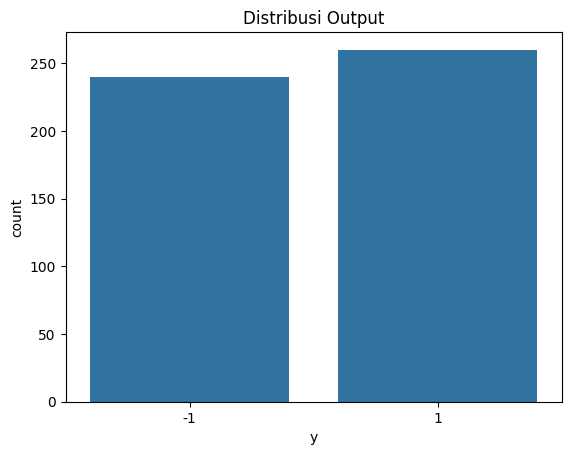

In [6]:
sns.countplot(x=data['y'])
plt.title('Distribusi Output')
plt.show()

## Split Data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Normalisasi

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model

### Perceptron

In [9]:
per_model = Perceptron(max_iter=1000)

per_model.fit(X_train, y_train)

y_pred_per = per_model.predict(X_test)

acc_per = accuracy_score(y_test, y_pred_per)

print("=== PERCEPTRON ===")
print("Accuracy :", acc_per)
print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred_per))

=== PERCEPTRON ===
Accuracy : 0.98
Confusion Matrix :
[[43  1]
 [ 1 55]]


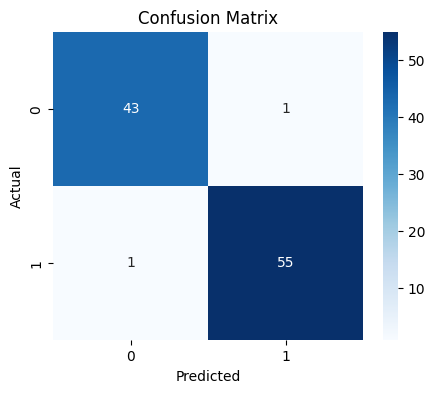

In [10]:
cm = confusion_matrix(y_test, y_pred_per)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Backpropagation

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

model = MLPClassifier(
    hidden_layer_sizes=(8, 8),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model :", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi Model : 1.0

Classification Report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        56

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



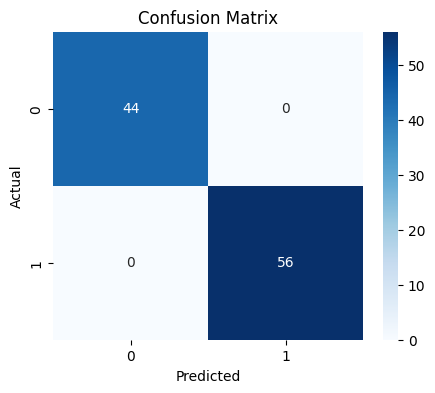

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

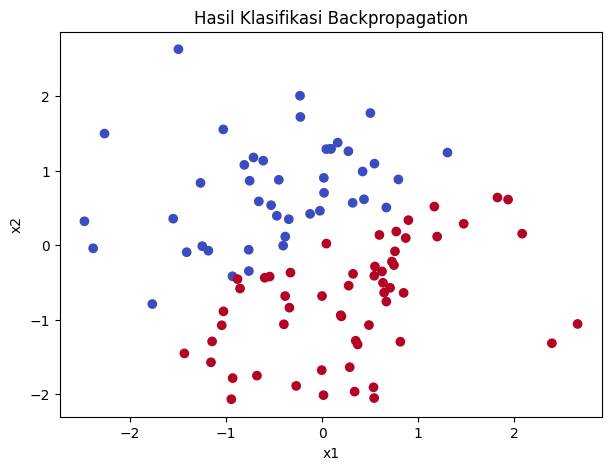

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c=y_pred,
    cmap='coolwarm'
)

plt.title('Hasil Klasifikasi Backpropagation')
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

### Hopfield

In [14]:
W = np.zeros((X_train.shape[1], X_train.shape[1]))

for i in range(len(X_train)):
    x = X_train[i]
    W += np.outer(x, x)

np.fill_diagonal(W, 0)

pred_hop = []

for x in X_test:

    output = np.sign(np.sum(W @ x))

    if output == 0:
        output = 1

    pred_hop.append(output)

pred_hop = np.array(pred_hop)

acc_hop = accuracy_score(y_test, pred_hop)

print("\n=== Hopfield ===")
print("Accuracy :", acc_hop)


=== Hopfield ===
Accuracy : 0.39


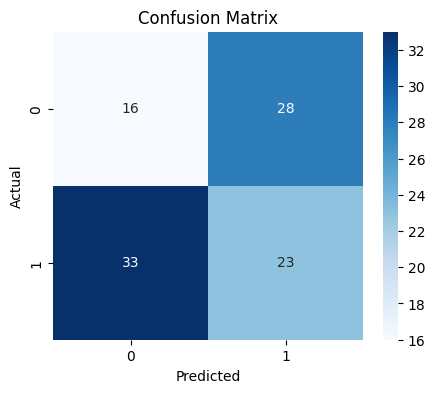

In [15]:
cm = confusion_matrix(y_test, pred_hop)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Perbandingan Akurasi

In [16]:
hasil_A = pd.DataFrame({
    'Metode': ['Perceptron', 'Hopfield', 'Backpropagation'],
    'Accuracy': [acc_per, acc_hop, accuracy]
})

print("\n=== Perbandingan Akurasi ===")
print(hasil_A)


=== Perbandingan Akurasi ===
            Metode  Accuracy
0       Perceptron      0.98
1         Hopfield      0.39
2  Backpropagation      1.00


# Dataset B

## Analisis Karakteristik Data

### Analisis Hubungan Antar Variabel

In [17]:
from google.colab import drive
drive.mount('/content/gdrive')
datab = pd.read_csv("/content/gdrive/My Drive/jst/B.csv")
datab.info()

print("\n=== Data ===")
print(datab)

X = datab[['0', '1', '2', '3']]
y = datab['4']

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       500 non-null    float64
 1   1       500 non-null    float64
 2   2       500 non-null    float64
 3   3       500 non-null    float64
 4   4       500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB

=== Data ===
       0    1    2    3    4
0    1.0  0.0  0.0  1.0  0.0
1    1.0  0.0  1.0 -1.0 -1.0
2    1.0  1.0  1.0 -1.0 -1.0
3    0.0  0.0  0.0 -1.0 -1.0
4    0.0  0.0  0.0 -1.0 -1.0
..   ...  ...  ...  ...  ...
495  1.0  1.0  0.0 -1.0 -1.0
496  0.0  1.0  0.0  0.0  1.0
497  1.0  1.0  0.0 -1.0 -1.0
498  0.0  1.0  1.0 -1.0 -1.0
499  0.0  1.0  0.0  0.0  1.0

[500 rows x 5 columns]


          0         1         2         3         4
0  1.000000 -0.079701  0.044984  0.186268 -0.215458
1 -0.079701  1.000000 -0.014058 -0.176688  0.225178
2  0.044984 -0.014058  1.000000 -0.560339 -0.561028
3  0.186268 -0.176688 -0.560339  1.000000  0.727407
4 -0.215458  0.225178 -0.561028  0.727407  1.000000


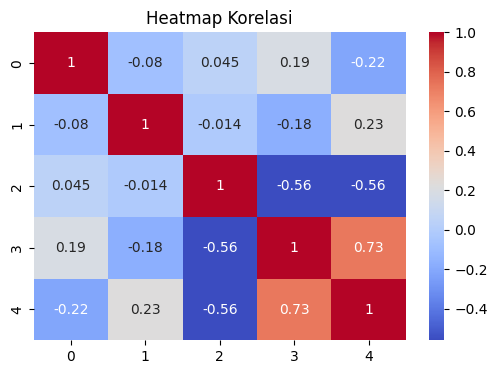

In [18]:
corrb = datab.corr()
print(corrb)

# Visualisasi heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corrb, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

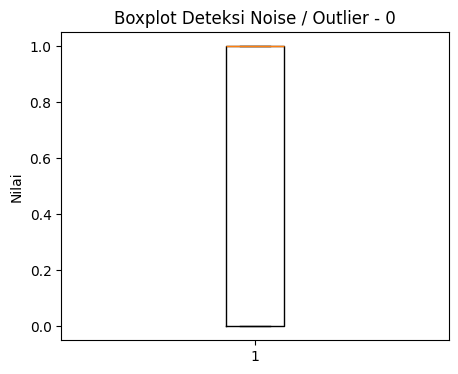

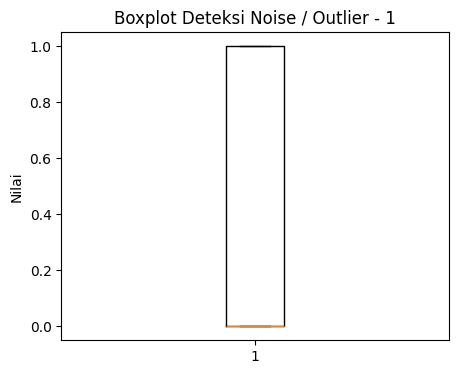

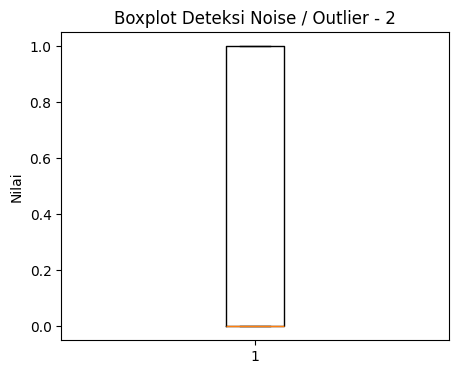

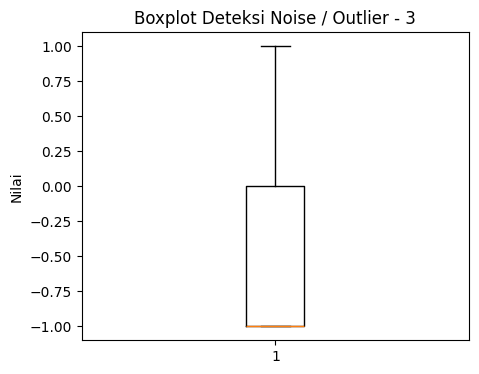

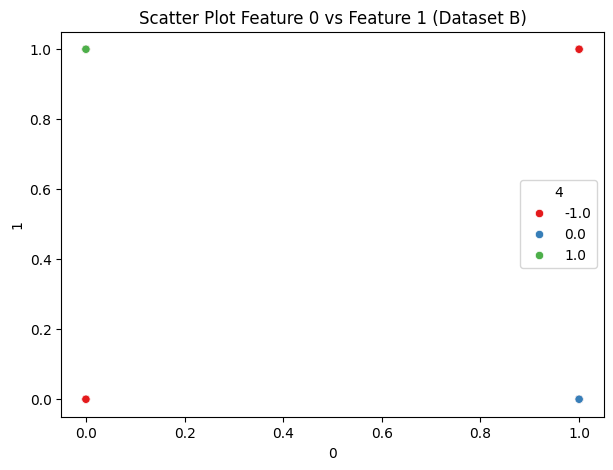

In [19]:
for col in ['0', '1','2','3']:

    plt.figure(figsize=(5,4))

    plt.boxplot(datab[col])

    plt.title(f'Boxplot Deteksi Noise / Outlier - {col}')
    plt.ylabel('Nilai')

    plt.show()

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=datab,
    x='0',
    y='1',
    hue='4',
    palette='Set1'
)

plt.title('Scatter Plot Feature 0 vs Feature 1 (Dataset B)')
plt.show()

### Identifikasi Bentuk Output

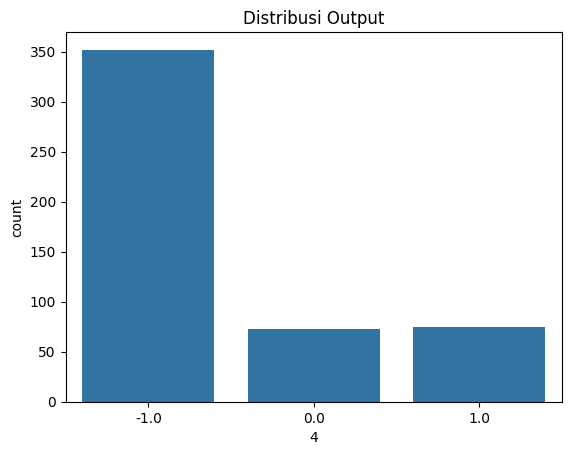

In [20]:
sns.countplot(x=datab['4'])
plt.title('Distribusi Output')
plt.show()

## Split Data

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Normalisasi

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model

### Backpropagation

In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

model = MLPClassifier(
    hidden_layer_sizes=(8, 8),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracyb = accuracy_score(y_test, y_pred)

print("Akurasi Model :", accuracyb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi Model : 1.0

Classification Report:
              precision    recall  f1-score   support

        -1.0       1.00      1.00      1.00        71
         0.0       1.00      1.00      1.00        12
         1.0       1.00      1.00      1.00        17

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



### Perceptron


=== ACCURACY ===
Accuracy : 0.57

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

          -1       0.44      0.67      0.53        36
           1       0.73      0.52      0.61        64

    accuracy                           0.57       100
   macro avg       0.58      0.59      0.57       100
weighted avg       0.63      0.57      0.58       100


=== CONFUSION MATRIX ===
[[24 12]
 [31 33]]


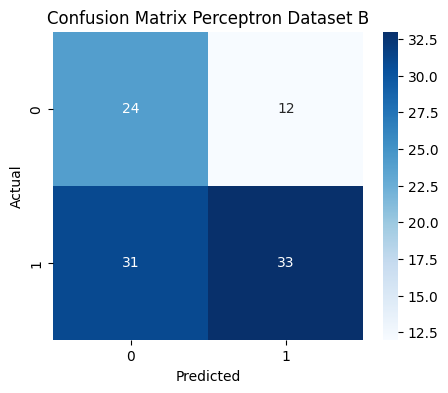

In [59]:
model = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42
)

# =====================================================
# TRAINING
# =====================================================

model.fit(X_train, y_train)

# =====================================================
# PREDIKSI
# =====================================================

y_pred = model.predict(X_test)

# =====================================================
# ACCURACY
# =====================================================

accuracyb3 = accuracy_score(y_test, y_pred)

print("\n=== ACCURACY ===")
print("Accuracy :", accuracyb3)

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_pred)

print("\n=== CONFUSION MATRIX ===")
print(cm)

# =====================================================
# VISUALISASI CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Perceptron Dataset B')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Hopfield

In [25]:
patterns = datab[['0', '1', '2', '3']]

n = patterns.shape[1]

# Inisialisasi matriks bobot
W = np.zeros((n, n))

# Hebbian Rule
for p in patterns.to_numpy():

    p = p.reshape(n, 1)

    W += p @ p.T

# diagonal = 0
np.fill_diagonal(W, 0)

print("\n=== BOBOT HOPFIELD ===")
print(W)

# =====================================================
# CONTOH UJI RECALL
# =====================================================

# Contoh input noisy
test = np.array([1, -1, 1, -1])

print("\n=== INPUT AWAL ===")
print(test)

# Update neuron
for _ in range(5):

    for i in range(n):

        net = np.dot(W[i], test)

        if net >= 0:
            test[i] = 1
        else:
            test[i] = -1

print("\n=== HASIL RECALL ===")
print(test)

# =====================================================
# FUNGSI RECALL
# =====================================================

def recall_pattern(W, pattern, steps=5):

    recalled = pattern.copy()

    for _ in range(steps):

        for i in range(len(pattern)):

            net = np.dot(W[i], recalled)

            if net >= 0:
                recalled[i] = 1
            else:
                recalled[i] = -1

    return recalled

# =====================================================
# PENGUJIAN ACCURACY
# =====================================================

correct = 0
total = len(patterns)

for p in patterns.to_numpy():

    # membuat noisy pattern
    noisy = p.copy()

    # membalik 1 bit
    noisy[0] *= -1

    # recall pola
    recalled = recall_pattern(W, noisy)

    # membandingkan dengan pola asli
    if np.array_equal(recalled, p):
        correct += 1

accuracyb2 = correct / total

print("\n=== HASIL ACCURACY HOPFIELD ===")
print("Accuracy :", accuracyb2)


=== BOBOT HOPFIELD ===
[[   0.  113.  123. -107.]
 [ 113.    0.  111. -168.]
 [ 123.  111.    0. -232.]
 [-107. -168. -232.    0.]]

=== INPUT AWAL ===
[ 1 -1  1 -1]

=== HASIL RECALL ===
[ 1  1  1 -1]

=== HASIL ACCURACY HOPFIELD ===
Accuracy : 0.112


=== CONFUSION MATRIX ===
[[33  0 38]
 [ 9  0  3]
 [ 7  0 10]]


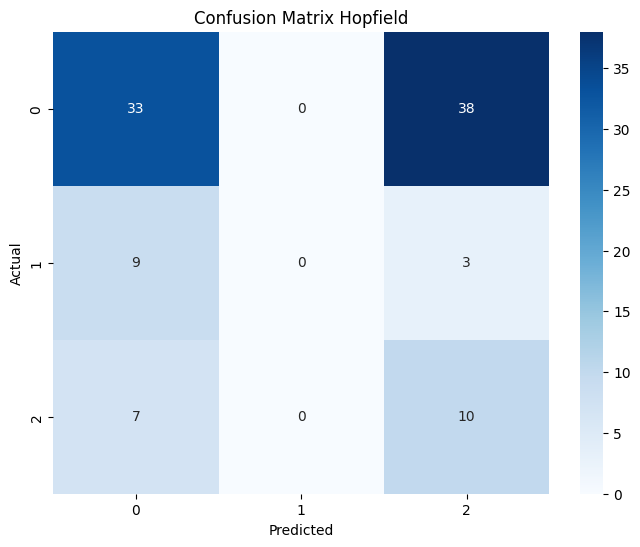

In [26]:
cm = confusion_matrix(y_test, pred_hop)

print("=== CONFUSION MATRIX ===")
print(cm)

# =====================================================
# VISUALISASI CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Hopfield')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Perbandingan Akurasi

In [61]:
hasil_B = pd.DataFrame({
    'Metode': ['Backpropagation','Perceptron', 'Hopfield'],
    'Accuracy': [accuracyb,accuracyb3, accuracyb2]
})

print("\n=== Perbandingan Akurasi ===")
print(hasil_B)


=== Perbandingan Akurasi ===
            Metode  Accuracy
0  Backpropagation     1.000
1       Perceptron     0.570
2         Hopfield     0.112


# Dataset C


## Analisis Karakteristik Data

### Analisis Hubungan Antar Variabel

In [28]:
from google.colab import drive
drive.mount('/content/gdrive')
datac = pd.read_csv("/content/gdrive/My Drive/jst/C.csv")
datac.info()

print("\n=== Data ===")
print(datac)

X = datac[['x1', 'x2']]
y = datac['y']

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      500 non-null    float64
 1   x2      500 non-null    float64
 2   y       500 non-null    float64
dtypes: float64(3)
memory usage: 11.8 KB

=== Data ===
            x1         x2          y
0    32.855067   6.287973  72.178752
1    36.363545  10.168401  91.082006
2    31.706839   9.628802  84.602583
3    37.491880   6.569926  85.440685
4    40.028791   6.919095  93.803831
..         ...        ...        ...
495  34.368621   9.327672  74.077484
496  34.358521   5.819296  68.549581
497  32.517869  14.744872  93.009228
498  41.476876   7.069859  95.906149
499  33.730124  11.070423  85.100404

[500 rows x 3 columns]


          x1        x2         y
x1  1.000000  0.007628  0.740486
x2  0.007628  1.000000  0.460721
y   0.740486  0.460721  1.000000


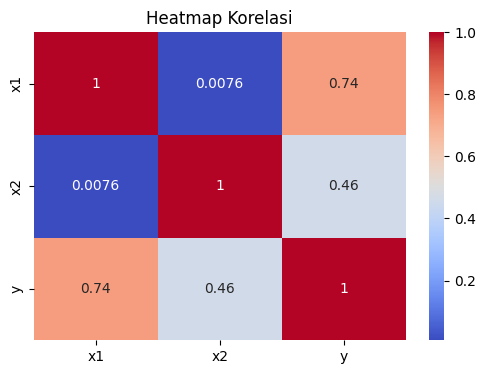

In [29]:
corrc = datac.corr()
print(corrc)

# Visualisasi heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corrc, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

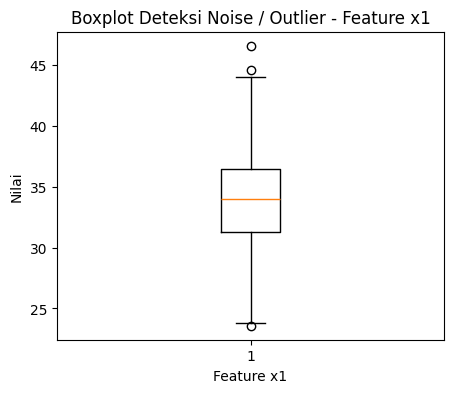

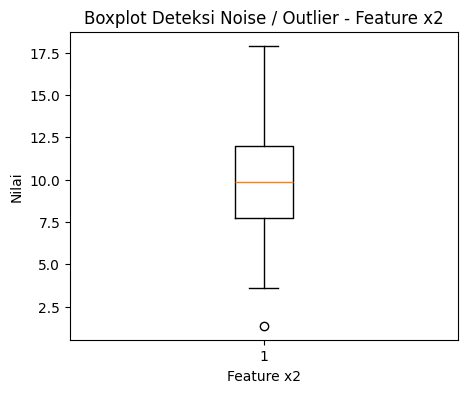

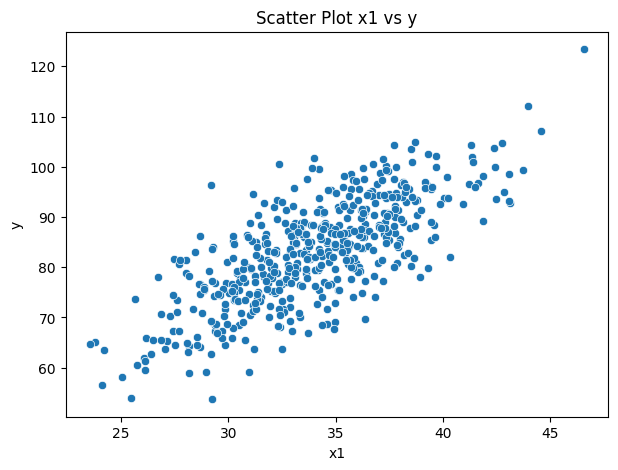

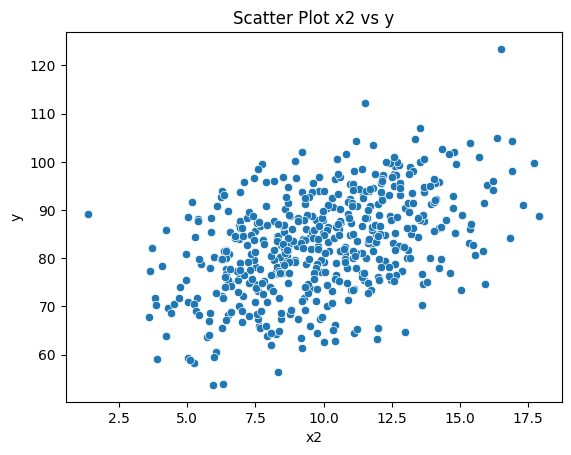

In [30]:
for col in ['x1', 'x2']:
    plt.figure(figsize=(5, 4))
    plt.boxplot(datac[col])
    plt.title(f'Boxplot Deteksi Noise / Outlier - Feature {col}')
    plt.xlabel(f'Feature {col}')
    plt.ylabel('Nilai')
    plt.show()

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=datac['x1'],
    y=datac['y']
)

plt.title('Scatter Plot x1 vs y')
plt.show()

sns.scatterplot(
    x=datac['x2'],
    y=datac['y']
)

plt.title('Scatter Plot x2 vs y')
plt.show()

### Identifikasi Bentuk Output

## Split Data

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Normalisasi

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model

### Delta Rule

In [33]:
np.random.seed(42)

learning_rate = 0.01
epochs = 100

n_features = X_train.shape[1]

# bobot dan bias
w = np.random.randn(n_features)
b = np.random.randn()

In [34]:
for epoch in range(epochs):

    for i in range(len(X_train)):

        x = X_train[i]
        target = y_train.iloc[i] # Changed to .iloc to access by positional index

        # output linear
        y_pred = np.dot(w, x) + b

        # error
        error = target - y_pred

        # update bobot
        w += learning_rate * error * x

        # update bias
        b += learning_rate * error

# =====================================================
# PREDIKSI
# =====================================================

predictions = []

for i in range(len(X_test)): # Also updated this loop to use index for y_test if needed, though not directly in the original error
    x = X_test[i]

    y_pred = np.dot(w, x) + b

    predictions.append(y_pred)

predictions = np.array(predictions)

# =====================================================
# EVALUASI
# =====================================================

mse = mean_squared_error(y_test, predictions)

print("\n=== HASIL DELTA RULE ===")
print("MSE :", mse)

# =====================================================
# MENGUBAH OUTPUT MENJADI KELAS
# =====================================================

threshold = np.mean(y_test)

y_test_class = np.where(y_test >= threshold, 1, 0)
pred_class = np.where(predictions >= threshold, 1, 0)

# =====================================================
# HITUNG ACCURACY
# =====================================================

from sklearn.metrics import accuracy_score

accuracyc = accuracy_score(y_test_class, pred_class)

print("\n=== ACCURACY DELTA RULE ===")
print("Accuracy :", accuracyc)


=== HASIL DELTA RULE ===
MSE : 26.59753412277483

=== ACCURACY DELTA RULE ===
Accuracy : 0.87


=== CONFUSION MATRIX ===
[[43  4]
 [ 9 44]]


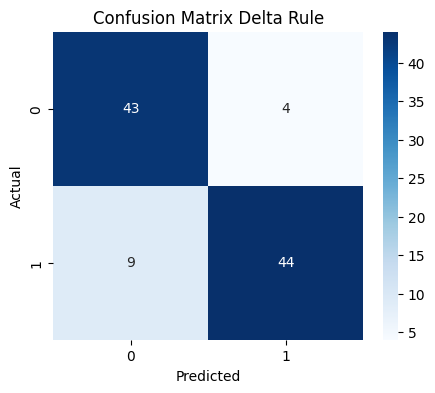

In [35]:
cm = confusion_matrix(y_test_class, pred_class)

print("=== CONFUSION MATRIX ===")
print(cm)

# =====================================================
# VISUALISASI CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Delta Rule')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Perceptron

In [36]:
np.random.seed(42)

learning_rate = 0.01
epochs = 100

n_features = X_train.shape[1]

w = np.random.randn(n_features)
b = np.random.randn()

# =====================================================
# TRAINING PERCEPTRON
# =====================================================

for epoch in range(epochs):

    for i in range(len(X_train)):

        x = X_train[i]
        target = y_train.iloc[i] # Fixed: Use .iloc to access by positional index

        net = np.dot(w, x) + b

        y_pred = 1 if net >= 0 else -1

        error = target - y_pred

        # update bobot
        w += learning_rate * error * x

        # update bias
        b += learning_rate * error

# =====================================================
# PREDIKSI
# =====================================================

predictions = []

for x in X_test:

    net = np.dot(w, x) + b

    y_pred = 1 if net >= 0 else -1

    predictions.append(y_pred)

# =====================================================
# EVALUASI
# =====================================================

# Convert continuous y_test to binary for classification metric compatibility
threshold = np.mean(y_test)
y_test_binary = np.where(y_test >= threshold, 1, -1) # Use -1 to match perceptron output

accuracyc2 = accuracy_score(y_test_binary, predictions)

print("\n=== HASIL PERCEPTRON ===")
print("Accuracy :", accuracyc2)


=== HASIL PERCEPTRON ===
Accuracy : 0.53


=== CONFUSION MATRIX PERCEPTRON ===
[[ 0 47]
 [ 0 53]]


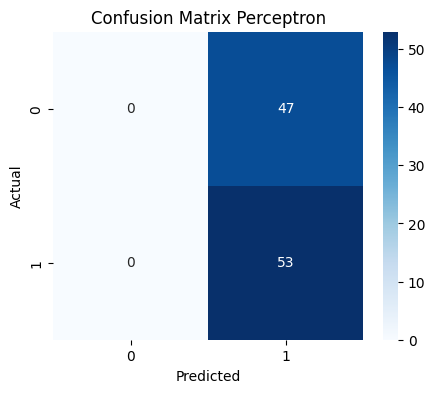

In [37]:
cm = confusion_matrix(y_test_binary, predictions)

print("=== CONFUSION MATRIX PERCEPTRON ===")
print(cm)

# =====================================================
# VISUALISASI CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Perceptron')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Perbandingan Akurasi

In [38]:
hasil_C = pd.DataFrame({
    'Metode': ['Delta Rule', 'Perceptron'],
    'Accuracy': [accuracyc, accuracyc2]
})

print("\n=== Perbandingan Akurasi ===")
print(hasil_C)


=== Perbandingan Akurasi ===
       Metode  Accuracy
0  Delta Rule      0.87
1  Perceptron      0.53


# Dataset D

## Analisis Karakteristik Data

### Analisis Hubungan Antar Variabel

In [39]:
from google.colab import drive
drive.mount('/content/gdrive')
datad = pd.read_csv("/content/gdrive/My Drive/jst/D.csv")
datad.info()

print("\n=== Data ===")
print(datad)

X = datad[['x1', 'x2', 'x3']]
y = datad['y']

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      500 non-null    float64
 1   x2      500 non-null    float64
 2   x3      500 non-null    float64
 3   y       500 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 15.8 KB

=== Data ===
            x1         x2         x3  y
0    38.147438  53.955219   9.249086  0
1    32.836822  69.324304  17.437655  1
2    37.133875  70.223806  15.078193  1
3    28.491240  31.321272  12.649394  0
4    35.616711  83.660739  14.575327  0
..         ...        ...        ... ..
495  27.099503  83.283014  14.185211  0
496  35.543319  34.313663  16.532750  1
497  25.894670  81.296007  10.886501  0
498  37.860259  43.517450  10.322350  1
499  36.854008  85.747189  15.653547  

          x1        x2        x3         y
x1  1.000000  0.003526 -0.032074  0.187532
x2  0.003526  1.000000 -0.016744 -0.242499
x3 -0.032074 -0.016744  1.000000  0.659372
y   0.187532 -0.242499  0.659372  1.000000


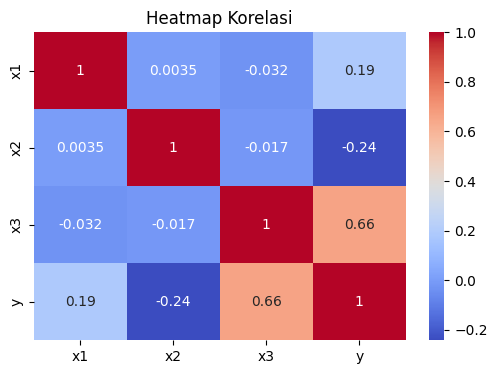

In [40]:
corrd = datad.corr()
print(corrd)

# Visualisasi heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corrd, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

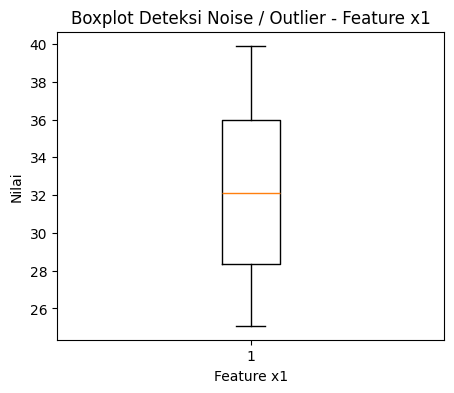

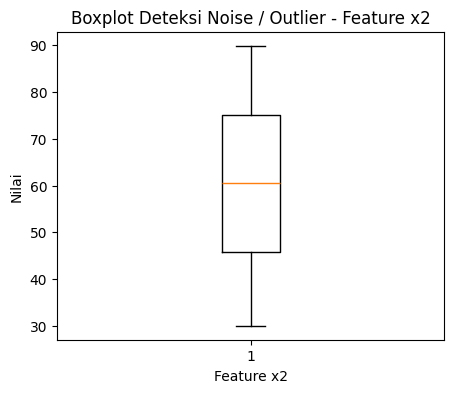

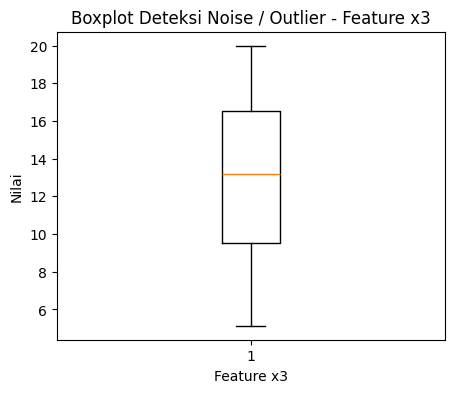

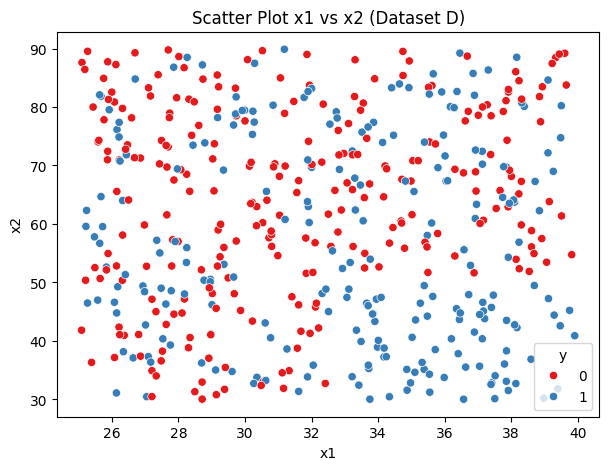

In [62]:
for col in ['x1', 'x2', 'x3']:
    plt.figure(figsize=(5, 4))
    plt.boxplot(datad[col])
    plt.title(f'Boxplot Deteksi Noise / Outlier - Feature {col}')
    plt.xlabel(f'Feature {col}')
    plt.ylabel('Nilai')
    plt.show()

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=datad, # Explicitly pass data=datad
    x='x1',      # Specify the x-axis column
    y='x2',      # Specify the y-axis column
    hue='y',
    palette='Set1'
)

plt.title('Scatter Plot x1 vs x2 (Dataset D)') # Add title for clarity
plt.show()

### Identifikasi Bentuk Output

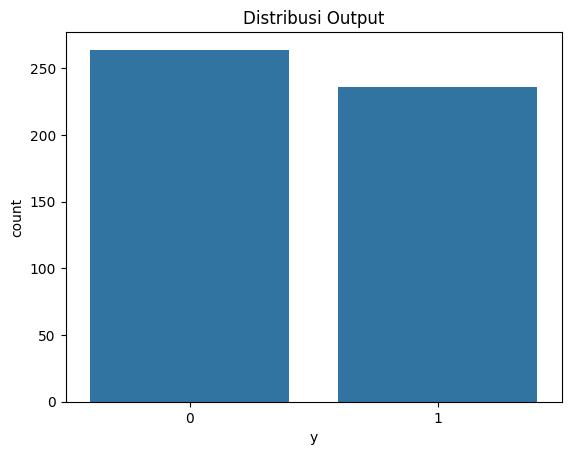

In [42]:
sns.countplot(x=datad['y'])

plt.title('Distribusi Output')

plt.show()

## Split Data

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Normalisasi

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model

### Perceptron

In [45]:
np.random.seed(42)

learning_rate = 0.01
epochs = 100

n_features = X_train.shape[1]

w = np.random.randn(n_features)
b = np.random.randn()

# =====================================================
# TRAINING PERCEPTRON
# =====================================================

for epoch in range(epochs):

    for i in range(len(X_train)):

        x = X_train[i] # Fixed: Direct indexing for NumPy array
        target = y_train.iloc[i]

        net = np.dot(w, x) + b

        y_pred = 1 if net >= 0 else -1

        error = target - y_pred

        w += learning_rate * error * x
        b += learning_rate * error

# =====================================================
# PREDIKSI
# =====================================================

predictions = []

for x_val in X_test:

    net = np.dot(w, x_val) + b

    y_pred = 1 if net >= 0 else -1

    predictions.append(y_pred)

# =====================================================
# ACCURACY
# =====================================================

acuracyd = accuracy_score(y_test, predictions)

print("\n=== ACCURACY PERCEPTRON ===")
print("Accuracy :", acuracyd)


=== ACCURACY PERCEPTRON ===
Accuracy : 0.3


[[ 0  0  0]
 [27  0 25]
 [18  0 30]]


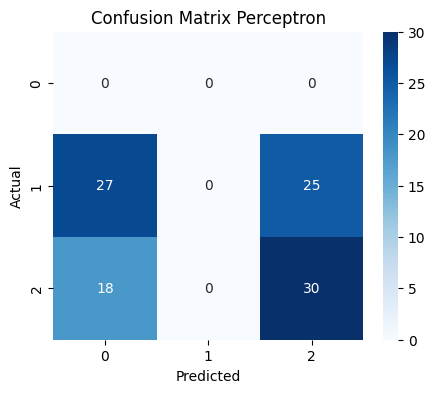

In [46]:
# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, predictions)

print(cm)

# =====================================================
# VISUALISASI
# =====================================================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Perceptron')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Backpropagation

In [47]:
model = MLPClassifier(
    hidden_layer_sizes=(8,8),
    activation='relu',
    solver='adam',
    max_iter=3000,
    random_state=42
)

# =====================================================
# TRAINING MODEL
# =====================================================

model.fit(X_train, y_train)

# =====================================================
# PREDIKSI
# =====================================================

y_pred = model.predict(X_test)

# =====================================================
# EVALUASI MODEL
# =====================================================

accuracyd2 = accuracy_score(y_test, y_pred)

print("\n=== HASIL EVALUASI ===")
print("Accuracy :", accuracyd2)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))


=== HASIL EVALUASI ===
Accuracy : 0.98

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        52
           1       1.00      0.96      0.98        48

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100




=== CONFUSION MATRIX ===
[[52  0]
 [ 2 46]]


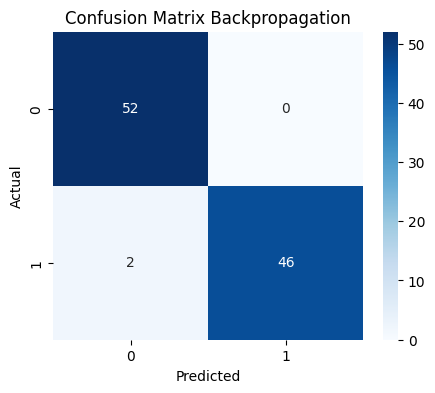

In [48]:
cm = confusion_matrix(y_test, y_pred)

print("\n=== CONFUSION MATRIX ===")
print(cm)

# =====================================================
# VISUALISASI CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Backpropagation')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Perbandingan Akurasi

In [49]:
hasil_D = pd.DataFrame({
    'Metode': ['Perceptron', 'Backpropagation'],
    'Accuracy': [acuracyd, accuracyd2]
})

print("\n=== Perbandingan Akurasi ===")
print(hasil_D)


=== Perbandingan Akurasi ===
            Metode  Accuracy
0       Perceptron      0.30
1  Backpropagation      0.98


# Dataset E

## Analisis Karakteristik Data

### Analisis Hubungan Antar Variabel

In [50]:
from google.colab import drive
drive.mount('/content/gdrive')
datae = pd.read_csv("/content/gdrive/My Drive/jst/E.csv")
datae.info()

print("\n=== Data ===")
print(datae)

# fitur 0-23
X = datae.iloc[:, :-1]

# target kolom terakhir
y = datae.iloc[:, -1]

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       500 non-null    int64
 1   1       500 non-null    int64
 2   2       500 non-null    int64
 3   3       500 non-null    int64
 4   4       500 non-null    int64
 5   5       500 non-null    int64
 6   6       500 non-null    int64
 7   7       500 non-null    int64
 8   8       500 non-null    int64
 9   9       500 non-null    int64
 10  10      500 non-null    int64
 11  11      500 non-null    int64
 12  12      500 non-null    int64
 13  13      500 non-null    int64
 14  14      500 non-null    int64
 15  15      500 non-null    int64
 16  16      500 non-null    int64
 17  17      500 non-null    int64
 18  18      500 non-null    int64
 19  19      500 non-null    

=== KORELASI ===
           0         1         2         3         4         5         6  \
0   1.000000 -0.003084 -0.009607 -0.037371  0.014783 -0.023170  0.013132   
1  -0.003084  1.000000  0.585197  0.231392 -0.208421  0.309831 -0.556988   
2  -0.009607  0.585197  1.000000  0.306289 -0.273986  0.308937 -0.633452   
3  -0.037371  0.231392  0.306289  1.000000 -0.561906 -0.249662 -0.302069   
4   0.014783 -0.208421 -0.273986 -0.561906  1.000000  0.286997  0.278752   
5  -0.023170  0.309831  0.308937 -0.249662  0.286997  1.000000 -0.349783   
6   0.013132 -0.556988 -0.633452 -0.302069  0.278752 -0.349783  1.000000   
7  -0.065644  0.481680  0.498774  0.270998 -0.256778  0.275671 -0.530158   
8  -0.041689  0.192695  0.290278  0.598446 -0.542015 -0.256113 -0.295651   
9   0.008272  0.316390  0.223817 -0.259645  0.297130  0.526722 -0.273050   
10  0.022683 -0.295588 -0.272712  0.293348 -0.270043 -0.524885  0.278421   
11  0.036976 -0.504896 -0.564399 -0.260111  0.211206 -0.329678  0.55328

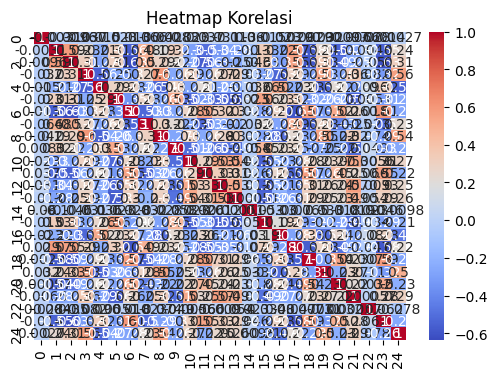

In [51]:
corre = datae.corr()

print("=== KORELASI ===")
print(corre)

plt.figure(figsize=(6,4))
sns.heatmap(corre, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

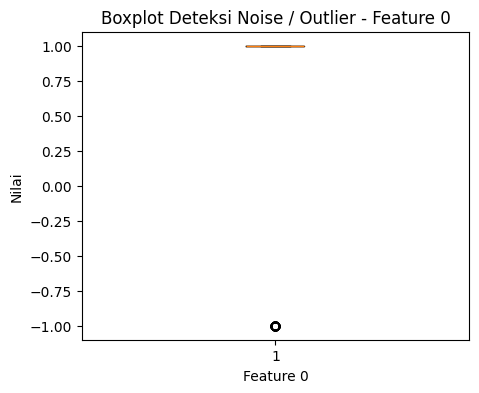

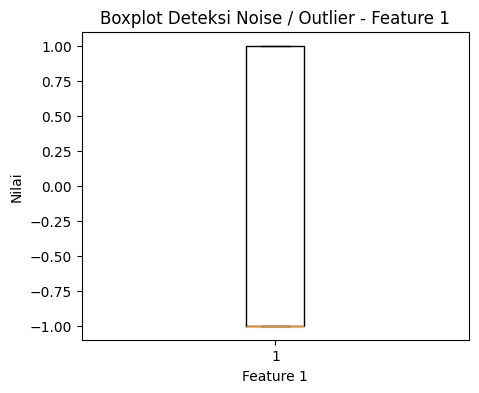

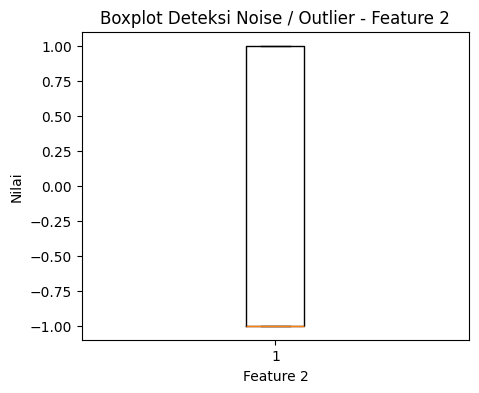

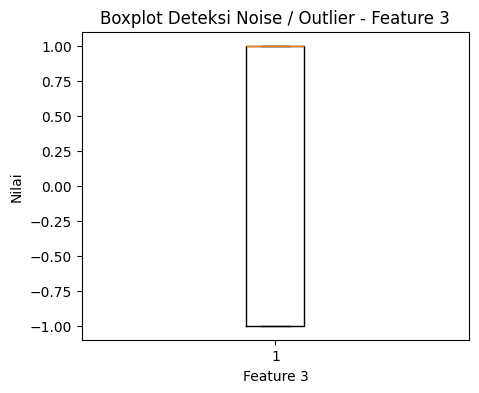

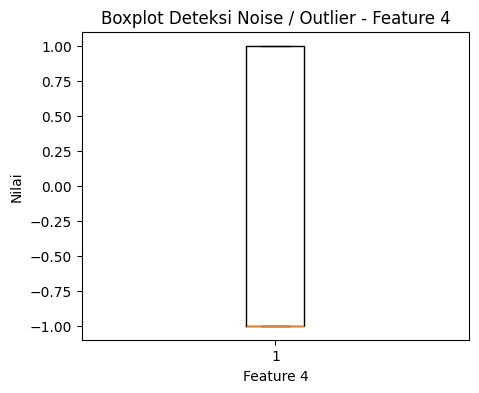

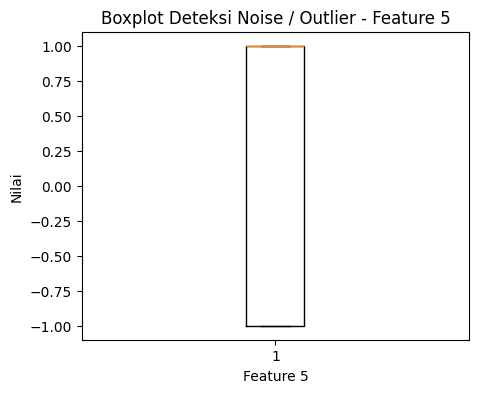

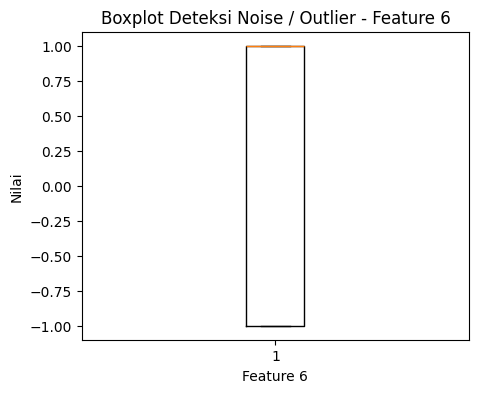

<Figure size 700x500 with 0 Axes>

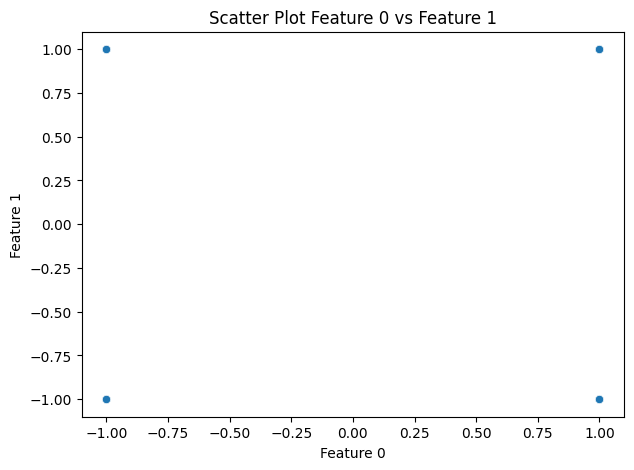

In [65]:
for col in ['0', '1', '2','3','4','5','6']:
    plt.figure(figsize=(5, 4))
    plt.boxplot(datae[col])
    plt.title(f'Boxplot Deteksi Noise / Outlier - Feature {col}')
    plt.xlabel(f'Feature {col}')
    plt.ylabel('Nilai')
    plt.show()

plt.figure(figsize=(7,5))

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=datae['0'],
    y=datae['1']
)

plt.title('Scatter Plot Feature 0 vs Feature 1')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

plt.show()

### Identifikasi Bentuk Output

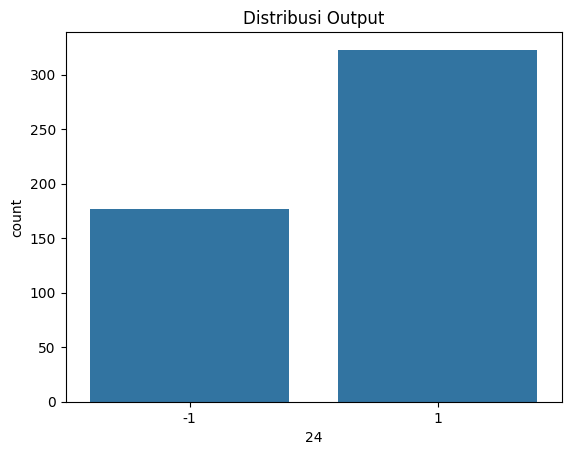

In [53]:
sns.countplot(x=y)

plt.title('Distribusi Output')

plt.show()

## Split Data

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Normalisasi

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model

### Hopfield

In [56]:
patterns = datae.copy() # Fixed: Use datae for Dataset E patterns
n = patterns.shape[1]

# inisialisasi bobot
W = np.zeros((n, n))

# Hebbian Rule
for p in patterns.to_numpy():

    p = p.reshape(n, 1)

    W += p @ p.T

# diagonal = 0
np.fill_diagonal(W, 0)

print("\n=== MATRIX BOBOT ===")
print(W)

# =====================================================
# CONTOH INPUT NOISY
# =====================================================

test = patterns.iloc[0].to_numpy().copy() # Get the first row as a NumPy array

# menambahkan noise (adjust indices for 25 features if needed, here just first element)
test[0] *= -1 # Example noise

print("\n=== INPUT NOISY ===")
print(test)

# =====================================================
# RECALL HOPFIELD
# =====================================================

recalled = test.copy()

for _ in range(10):

    for i in range(n):

        net = np.dot(W[i], recalled)

        if net >= 0:
            recalled[i] = 1
        else:
            recalled[i] = -1

print("\n=== HASIL RECALL ===")
print(recalled)

# =====================================================
# POLA ASLI
# =====================================================

print("\n=== POLA ASLI ===")
print(patterns.iloc[0].to_numpy())

# =====================================================
# ACCURACY RECALL
# =====================================================

correct = 0
total = len(patterns)

for p_original in patterns.to_numpy():

    noisy = p_original.copy()

    # menambahkan noise (e.g., flip first element)
    noisy[0] *= -1

    recalled = noisy.copy()

    for _ in range(10):

        for i in range(n):

            net = np.dot(W[i], recalled)

            if net >= 0:
                recalled[i] = 1
            else:
                recalled[i] = -1

    if np.array_equal(recalled, p_original):
        correct += 1

accuracye = correct / total

print("\n=== ACCURACY HOPFIELD ===")
print("Accuracy :", accuracye)


=== MATRIX BOBOT ===
[[   0.  -86. -104.  100. -106.   54.   98. -100.   84.   82.  -86.   96.
   -86.  -88. -260.   64. -100.  -68.   96.  100.  112.  -80.  254.   96.
   106.]
 [ -86.    0.  306.   70.  -60.  128. -292.  254.   58.  124. -108. -266.
  -128. -106.   58.  134.  -74.  298. -302.   86. -286. -106.  -84. -290.
    76.]
 [-104.  306.    0.   96.  -82.  122. -330.  264.   96.   74.  -90. -296.
  -106.  -84.   92.  128. -104.  288. -312.  120. -268.  -88. -118. -328.
   102.]
 [ 100.   70.   96.    0. -302.  -90.  -98.   92.  316.  -86.   94.  -84.
    82.  100. -128.  -96. -284.  100.  -92.  284.  -68.  132.   86. -104.
   302.]
 [-106.  -60.  -82. -302.    0.  108.   88.  -86. -290.  104.  -84.   62.
   -76.  -90.  106.   90.  278.  -74.   66. -282.   50. -102.  -80.  102.
  -292.]
 [  54.  128.  122.  -90.  108.    0. -144.  114.  -98.  272. -272. -138.
  -284. -298.  -58.  286.   86.  134. -130. -102.  -94. -286.   64. -122.
  -100.]
 [  98. -292. -330.  -98.   88. -144

### Backpropagation


=== ACCURACY BACKPROPAGATION ===
Accuracy : 0.86

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

          -1       0.87      0.72      0.79        36
           1       0.86      0.94      0.90        64

    accuracy                           0.86       100
   macro avg       0.86      0.83      0.84       100
weighted avg       0.86      0.86      0.86       100


=== CONFUSION MATRIX ===
[[26 10]
 [ 4 60]]


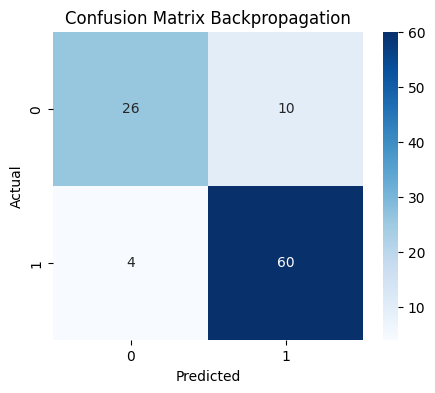

In [57]:
model = MLPClassifier(
    hidden_layer_sizes=(16,16),
    activation='relu',
    solver='adam',
    max_iter=3000,
    random_state=42
)

# =====================================================
# TRAINING
# =====================================================

model.fit(X_train, y_train)

# =====================================================
# PREDIKSI
# =====================================================

y_pred = model.predict(X_test)

# =====================================================
# ACCURACY
# =====================================================

accuracye2 = accuracy_score(y_test, y_pred)

print("\n=== ACCURACY BACKPROPAGATION ===")
print("Accuracy :", accuracye2)

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_pred)

print("\n=== CONFUSION MATRIX ===")
print(cm)

# =====================================================
# VISUALISASI CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Backpropagation')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Perbandingan Akurasi

In [58]:
hasil_E = pd.DataFrame({
    'Metode': ['Hopfield', 'Backpropagation'],
    'Accuracy': [accuracye, accuracye2]
})

print("\n=== Perbandingan Akurasi ===")
print(hasil_E)


=== Perbandingan Akurasi ===
            Metode  Accuracy
0         Hopfield      0.00
1  Backpropagation      0.86
